Train: 37518 событий, 56 пользователей
Test: 7125 событий, 34 пользователей

Создание последовательностей...
Создано 56 тренировочных и 34 тестовых последовательностей

Создание нейронной сети...



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_a_gate        │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_a_time        │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_b_gate        │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_b_time        │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 32)        │     42,016 │ input_a_gate[0][… │
│ (Functional)        │                   │            │ input_a_time[0][… │
│                     │                   │            │ input_b_gate[0][… │
│                     │                   │            │ input_b_time[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,049 (164.25 KB)

 Trainable params: 42,049 (164.25 KB)

 Non-trainable params: 0 (0.00 B)

Создание тренировочных пар...

Обучение нейронной сети...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 102s 170ms/step - accuracy: 0.8211 - loss: 0.4522 - val_accuracy: 0.9392 - val_loss: 0.1492
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 162ms/step - accuracy: 0.8986 - loss: 0.3010 - val_accuracy: 0.9380 - val_loss: 0.1203
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 164ms/step - accuracy: 0.9113 - loss: 0.2759 - val_accuracy: 0.9555 - val_loss: 0.0972
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 157ms/step - accuracy: 0.9159 - loss: 0.2634 - val_accuracy: 0.9128 - val_loss: 0.1475
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 169ms/step - accuracy: 0.9018 - loss: 0.2895 - val_accuracy: 0.9505 - val_loss: 0.1045
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 199ms/step - accuracy: 0.9212 - loss: 0.2413 - val_accuracy: 0.9635 - val_loss: 0.0850
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 133ms/step - accuracy: 0.9296 - loss: 0.2137 - val_accuracy: 0.9530 - val_loss: 0.0850
Epoch 8/20
500/500 ━━━━

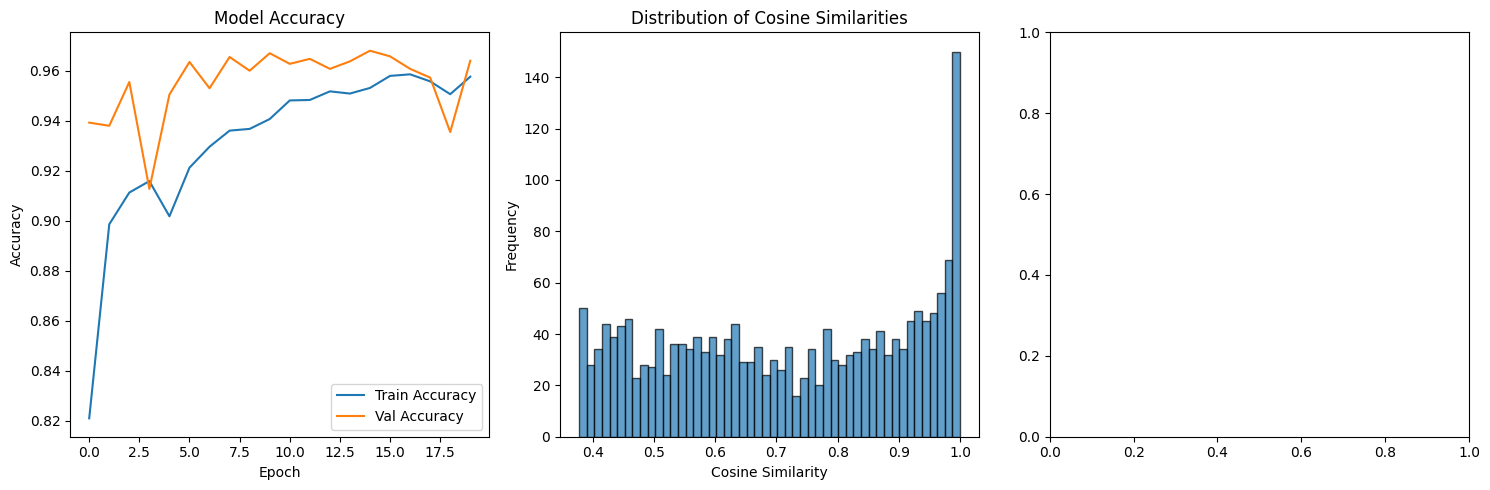

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from collections import defaultdict
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('train_final.csv')
test_df = pd.read_csv('test_final.csv')

train_df['ts_dt'] = pd.to_datetime(train_df['ts'])
test_df['ts_dt'] = pd.to_datetime(test_df['ts'])

train_df = train_df.sort_values(['user_id', 'ts_dt'])
test_df = test_df.sort_values(['user_word', 'ts_dt'])

def create_sequences(df, id_col, max_len=50):
    """creates sequences of gate_id and time intervals for each user"""
    
    sequences = {}
    time_seqs = {}
    scaler = MinMaxScaler()
    
    all_gates = df['gate_id'].values.reshape(-1, 1)
    scaler.fit(all_gates)
    
    for user_id in df[id_col].unique():
        user_data = df[df[id_col] == user_id].copy()
        
        gates_norm = scaler.transform(user_data['gate_id'].values.reshape(-1, 1)).flatten()
        
        user_data['time_diff'] = user_data['ts_dt'].diff().dt.total_seconds().fillna(0) / 3600
        time_intervals = user_data['time_diff'].values
        
        if len(gates_norm) >= max_len:
            gates_seq = gates_norm[:max_len]
            time_seq = time_intervals[:max_len]
        else:
            gates_seq = np.pad(gates_norm, (0, max_len - len(gates_norm)), 'constant')
            time_seq = np.pad(time_intervals, (0, max_len - len(time_intervals)), 'constant')
        
        sequences[user_id] = gates_seq
        time_seqs[user_id] = time_seq
    
    return sequences, time_seqs, scaler

max_sequence_length = 100

train_sequences, train_times, gate_scaler = create_sequences(train_df, 'user_id', max_sequence_length)
test_sequences, test_times, _ = create_sequences(test_df, 'user_word', max_sequence_length)

# 2. create the Siamese Neural Network
def create_siamese_network(sequence_length):
    """creates a Siamese Neural Network model"""
    
    input_a_gate = layers.Input(shape=(sequence_length, 1), name='input_a_gate')
    input_a_time = layers.Input(shape=(sequence_length, 1), name='input_a_time')
    
    input_b_gate = layers.Input(shape=(sequence_length, 1), name='input_b_gate')
    input_b_time = layers.Input(shape=(sequence_length, 1), name='input_b_time')
    
    def create_encoder():
        gate_input = layers.Input(shape=(sequence_length, 1))
        gate_lstm = layers.LSTM(64, return_sequences=True)(gate_input)
        gate_lstm = layers.LSTM(32)(gate_lstm)
        
        time_input = layers.Input(shape=(sequence_length, 1))
        time_lstm = layers.LSTM(32, return_sequences=True)(time_input)
        time_lstm = layers.LSTM(16)(time_lstm)
        
        merged = layers.Concatenate()([gate_lstm, time_lstm])
        
        dense = layers.Dense(64, activation='relu')(merged)
        dense = layers.Dropout(0.3)(dense)
        dense = layers.Dense(32, activation='relu')(dense)
        
        return keras.Model(inputs=[gate_input, time_input], outputs=dense)
    
    encoder = create_encoder()
    
    encoded_a = encoder([input_a_gate, input_a_time])
    encoded_b = encoder([input_b_gate, input_b_time])
    
    l1_distance = layers.Lambda(lambda tensors: keras.backend.abs(tensors[0] - tensors[1]))([encoded_a, encoded_b])
    
    output = layers.Dense(1, activation='sigmoid')(l1_distance)
    
    model = keras.Model(
        inputs=[input_a_gate, input_a_time, input_b_gate, input_b_time],
        outputs=output
    )
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model, encoder

print("\nCreating Siamese Neural Network...")
model, encoder = create_siamese_network(max_sequence_length)
model.summary()

def create_training_pairs(train_sequences, train_times, num_pairs=10000):
    """creates training pairs for the Siamese network"""
    
    user_ids = list(train_sequences.keys())
    n_users = len(user_ids)
    
    X1_gate, X1_time, X2_gate, X2_time, y = [], [], [], [], []
    
    for _ in range(num_pairs // 2):
        user_id = np.random.choice(user_ids)
        
        X1_gate.append(train_sequences[user_id].reshape(-1, 1))
        X1_time.append(train_times[user_id].reshape(-1, 1))
        X2_gate.append(train_sequences[user_id].reshape(-1, 1))
        X2_time.append(train_times[user_id].reshape(-1, 1))
        y.append(1)  
    
    for _ in range(num_pairs // 2):
        user_id1, user_id2 = np.random.choice(user_ids, 2, replace=False)
        
        X1_gate.append(train_sequences[user_id1].reshape(-1, 1))
        X1_time.append(train_times[user_id1].reshape(-1, 1))
        X2_gate.append(train_sequences[user_id2].reshape(-1, 1))
        X2_time.append(train_times[user_id2].reshape(-1, 1))
        y.append(0)  
    
    return (
        np.array(X1_gate), np.array(X1_time),
        np.array(X2_gate), np.array(X2_time),
        np.array(y)
    )

print("Creating training pairs...")
X1_gate, X1_time, X2_gate, X2_time, y = create_training_pairs(train_sequences, train_times, num_pairs=20000)

# 4. learn the model
print("\nlearning the model...")
history = model.fit(
    [X1_gate, X1_time, X2_gate, X2_time],
    y,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

print("\nCreating embeddings...")

def get_embeddings(sequences, times, encoder):
    """Gets embeddings for all sequences"""
    
    embeddings = {}
    
    for user_id in sequences.keys():
        gate_seq = sequences[user_id].reshape(1, -1, 1)
        time_seq = times[user_id].reshape(1, -1, 1)
        
        embedding = encoder.predict([gate_seq, time_seq], verbose=0)
        embeddings[user_id] = embedding.flatten()
    
    return embeddings

train_embeddings = get_embeddings(train_sequences, train_times, encoder)
test_embeddings = get_embeddings(test_sequences, test_times, encoder)

print(f"Создано {len(train_embeddings)} тренировочных и {len(test_embeddings)} тестовых эмбеддингов")

# Transform embeddings to matrices
train_ids = list(train_embeddings.keys())
test_words = list(test_embeddings.keys())

train_matrix = np.array([train_embeddings[id] for id in train_ids])
test_matrix = np.array([test_embeddings[word] for word in test_words])

similarity_matrix = cosine_similarity(test_matrix, train_matrix)

matches = {}
used_train_ids = set()

test_quality = []
for i, word in enumerate(test_words):
    quality = np.linalg.norm(test_matrix[i]) / len(test_embeddings[word])
    test_quality.append((word, quality, i))

test_quality.sort(key=lambda x: x[1], reverse=True)

for word, quality, idx in test_quality:
    similarities = similarity_matrix[idx]
    
    best_match_idx = -1
    best_similarity = -1
    
    for j, sim in enumerate(similarities):
        train_id = train_ids[j]
        if train_id not in used_train_ids and sim > best_similarity:
            best_similarity = sim
            best_match_idx = j
    
    if best_similarity > 0.6:
        matches[word] = train_ids[best_match_idx]
        used_train_ids.add(train_ids[best_match_idx])
        print(f"compared: {word} -> {train_ids[best_match_idx]} (similarity: {best_similarity:.3f})")
    else:
        matches[word] = -999

def optimize_matches(matches, similarity_matrix, train_ids, test_words, n_iterations=10):
    """optimizes matches by swapping to improve total similarity score"""
    
    best_matches = matches.copy()
    best_score = sum(
        similarity_matrix[
            test_words.index(word), 
            train_ids.index(best_matches[word])
        ] if best_matches[word] != -999 else 0
        for word in best_matches
    )
    
    for iteration in range(n_iterations):
        improved = False
        
        matched_words = [w for w in matches if matches[w] != -999]
        
        if len(matched_words) >= 2:
            for i in range(len(matched_words)):
                for j in range(i + 1, len(matched_words)):
                    word1 = matched_words[i]
                    word2 = matched_words[j]
                    
                    id1 = matches[word1]
                    id2 = matches[word2]
                    
                    new_score = best_score
                    new_score -= similarity_matrix[test_words.index(word1), train_ids.index(id1)]
                    new_score -= similarity_matrix[test_words.index(word2), train_ids.index(id2)]
                    new_score += similarity_matrix[test_words.index(word1), train_ids.index(id2)]
                    new_score += similarity_matrix[test_words.index(word2), train_ids.index(id1)]
                    
                    if new_score > best_score:
                        best_matches[word1] = id2
                        best_matches[word2] = id1
                        best_score = new_score
                        improved = True
        
        if not improved:
            break
    
    return best_matches, best_score

optimized_matches, final_score = optimize_matches(
    matches, similarity_matrix, train_ids, test_words, n_iterations=5
)

print(f"Final score: {final_score:.3f}")

result_df = pd.DataFrame(
    [(word, optimized_matches[word]) for word in test_words],
    columns=['user_word', 'preds']
)

result_df.to_csv('deep_learning_matching.csv', index=False)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

similarities_flat = similarity_matrix.flatten()
axes[1].hist(similarities_flat, bins=50, alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Cosine Similarities')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

if 'user_id' in test_df.columns:
    correct_mask = (result_df['preds'] == result_df['user_id']) & (result_df['preds'] != -999)
    wrong_mask = (result_df['preds'] != result_df['user_id']) & (result_df['preds'] != -999)
    
    correct_sims = []
    wrong_sims = []
    
    for idx, row in result_df.iterrows():
        if row['preds'] != -999:
            word_idx = test_words.index(row['user_word'])
            train_idx = train_ids.index(row['preds'])
            sim = similarity_matrix[word_idx, train_idx]
            
            if row['preds'] == row['user_id']:
                correct_sims.append(sim)
            else:
                wrong_sims.append(sim)
    
    axes[2].hist(correct_sims, bins=30, alpha=0.7, label='Correct', edgecolor='green')
    axes[2].hist(wrong_sims, bins=30, alpha=0.7, label='Wrong', edgecolor='red')
    axes[2].set_title('Similarity by Match Quality')
    axes[2].set_xlabel('Cosine Similarity')
    axes[2].set_ylabel('Frequency')
    axes[2].legend()

plt.tight_layout()
plt.savefig('matching_analysis.png', dpi=150)
plt.show()

In [3]:
import tensorflow as tf
print(tf.__version__)

2.20.0
